In [1]:
import sys
sys.path.append("..")

import os
import ezsdr
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
# EzSDRClientのインスタンスを作成
client = ezsdr.EzSDRClient("127.0.0.1", 8888)

complex_int8 = np.dtype([('real', np.int8), ('imag', np.int8)])

# 送受信機のインスタンスを作成
TX0 = ezsdr.CyclicTransmitter(client, "TX0", dtype=complex_int8)
RX0 = ezsdr.CyclicReceiver(client, "RX0", dtype=complex_int8)

In [10]:
nSamples = 10000
qpsk_constellation = np.array([1+1j, -1+1j, -1-1j, 1-1j]) / np.sqrt(2) * 64

sig0 = np.repeat(np.random.choice(qpsk_constellation, nSamples//4), 4)
sig0_ci8 = np.zeros(nSamples, dtype=complex_int8)
sig0_ci8['real'] = sig0.real.astype(np.int8)
sig0_ci8['imag'] = sig0.imag.astype(np.int8)

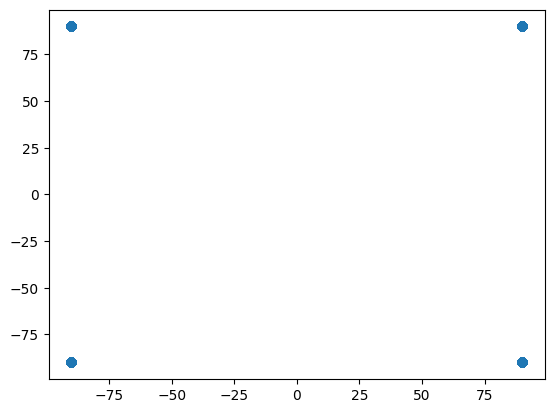

In [4]:
plt.plot(sig0_ci8['real'], sig0_ci8['imag'], 'o')

In [11]:
TX0.transmit([sig0_ci8])

In [13]:
recv0 = RX0.receive(nSamples)[0]

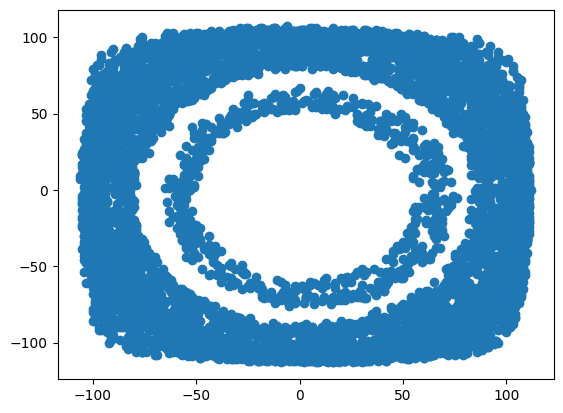

In [15]:
plt.plot(recv0['real'], recv0['imag'], 'o')

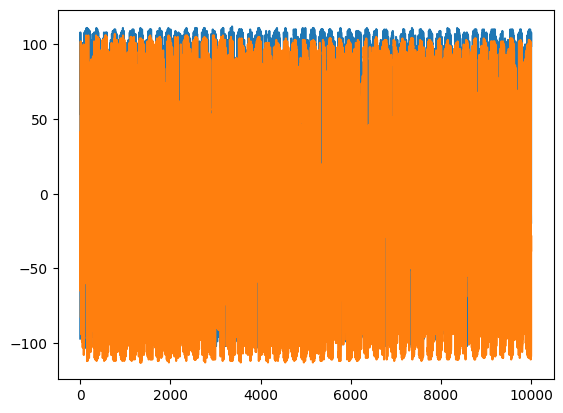

In [16]:
plt.plot(recv0['real'])
plt.plot(recv0['imag'])